# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

## 1. My rule and its reason codes

Two things happen here, before any queue gets built:

1. **Re-confirm the two signals this rule leans on**, standalone in this
   notebook (not just referenced from `w04_signal_audit.ipynb`) — one bucket
   table each, n printed, one-word verdict. Both were validated in the audit:
   - `ctr_vs_position` (flag-linked → CTR-fix logic) — MIXED overall, but a
     real effect in the mid-range position band.
   - `volume` (`search_volume`, → quick-win) — OPPOSITE of the original
     hypothesis; direction flipped: low volume predicts decline, not high.

2. **Design the rule** — a single score built from these two signals, exactly
   one reason code per row (whichever signal drove that row's score higher),
   and an action label from score thresholds. No future-window or
   label-derived inputs. The rule is *defined* here as a reusable function;
   it gets *applied* to the full dataset in Section 2.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_PATH = "data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_PATH)
print(f"rows: {len(df):,}  cols: {df.shape[1]}")

rows: 30,000  cols: 44


In [3]:
def outcome_flag(frame, outcome_col="trend_direction", positive_value="down"):
    return (frame[outcome_col] == positive_value).astype(int)

In [4]:
def ctr_vs_position_table(frame, position_col="avg_position", ctr_col="ctr", n_position_bins=3, n_ctr_bins=3):
    work = frame.dropna(subset=[position_col, ctr_col])[[position_col, ctr_col]].copy()
    work["outcome"] = outcome_flag(frame.loc[work.index])
    work["position_bucket"] = pd.qcut(work[position_col], q=n_position_bins, duplicates="drop")

    rows = []
    for pos_bucket, grp in work.groupby("position_bucket", observed=True):
        try:
            grp = grp.copy()
            grp["ctr_bucket"] = pd.qcut(grp[ctr_col], q=n_ctr_bins, duplicates="drop")
        except ValueError:
            continue
        sub = (
            grp.groupby("ctr_bucket", observed=True)
            .agg(n=("outcome", "size"), outcome_rate=("outcome", "mean"))
            .reset_index()
        )
        sub.insert(0, "position_bucket", str(pos_bucket))
        rows.append(sub)

    table = pd.concat(rows, ignore_index=True)
    table["outcome_rate"] = table["outcome_rate"].round(3)
    return table

ctr_position_table = ctr_vs_position_table(df)
print(ctr_position_table.to_string(index=False))
print("\nVerdict: MIXED — holds only in the mid-range position band (see w04_signal_audit.ipynb for full audit).")

position_bucket     ctr_bucket    n  outcome_rate
  (-0.001, 7.4] (-0.001, 0.28] 6789         0.478
  (-0.001, 7.4]  (0.28, 100.0] 3300         0.502
    (7.4, 17.2] (-0.001, 0.23] 6690         0.625
    (7.4, 17.2]  (0.23, 100.0] 3224         0.557
  (17.2, 245.0] (-0.001, 0.11] 6802         0.537
  (17.2, 245.0]  (0.11, 100.0] 3195         0.541

Verdict: MIXED — holds only in the mid-range position band (see w04_signal_audit.ipynb for full audit).


In [5]:
def bucket_table(frame, col, n_bins=4, outcome_col="trend_direction", positive_value="down"):
    n_null = frame[col].isna().sum()
    work = frame.dropna(subset=[col])[[col]].copy()
    work["outcome"] = outcome_flag(frame.loc[work.index], outcome_col, positive_value)
    try:
        work["bucket"] = pd.qcut(work[col], q=n_bins, duplicates="drop")
    except ValueError:
        work["bucket"] = pd.cut(work[col], bins=n_bins)
    table = (
        work.groupby("bucket", observed=True)
        .agg(n=("outcome", "size"), outcome_rate=("outcome", "mean"))
        .reset_index()
        .sort_values("bucket")
    )
    table["outcome_rate"] = table["outcome_rate"].round(3)
    print(f"[{col}] dropped {n_null} null rows ({n_null/len(frame):.1%})")
    return table

volume_table = bucket_table(df, "search_volume")
print(volume_table.to_string(index=False))
print("\nVerdict: OPPOSITE — low search_volume predicts decline, not high (direction flipped from original hypothesis).")

[search_volume] dropped 2468 null rows (8.2%)
         bucket     n  outcome_rate
 (-0.001, 10.0] 18392         0.590
   (10.0, 20.0]  2290         0.516
(20.0, 74000.0]  6850         0.509

Verdict: OPPOSITE — low search_volume predicts decline, not high (direction flipped from original hypothesis).


In [6]:
def score_row(row):
    """
    Transparent hand-rule. Two components, each backed by an audited signal:

    1. Volume component (flipped direction, per audit): lower search_volume -> higher score.
    2. CTR-vs-position component: low CTR *within the mid-range position band*
       (roughly positions 7-17, per the audit's position_bucket split) -> higher score.
       Outside that band, this component contributes nothing — the audit showed
       the effect doesn't hold elsewhere.

    Returns (score, reason_code).
    """
    score = 0
    reasons = []

    # -- Volume component --
    sv = row.get("search_volume", np.nan)
    if pd.notna(sv):
        if sv <= 10:
            score += 2
            reasons.append(("LOW_VOLUME", 2))
        elif sv <= 20:
            score += 1
            reasons.append(("LOW_VOLUME", 1))

    # -- CTR-vs-position component (mid-range band only) --
    pos = row.get("avg_position", np.nan)
    ctr = row.get("ctr", np.nan)
    if pd.notna(pos) and pd.notna(ctr) and 7.4 < pos <= 17.2:
        if ctr <= 0.23:
            score += 3
            reasons.append(("CTR_GAP_MIDPOS", 3))

    # -- Single reason code: whichever component contributed most --
    reason_code = max(reasons, key=lambda r: r[1])[0] if reasons else "NO_SIGNAL"

    # -- Action label from score thresholds --
    if score >= 3:
        action = "priority_fix"
    elif score >= 1:
        action = "monitor"
    else:
        action = "no_action"

    return pd.Series({"score": score, "reason_code": reason_code, "action": action})

# Smoke test on a small sample before applying to the full dataframe in Section 2
sample_scores = df.head(5).apply(score_row, axis=1)
pd.concat([df.head(5)[["content_id", "search_volume", "avg_position", "ctr"]], sample_scores], axis=1)

,content_id,search_volume,avg_position,ctr,score,reason_code,action
0,content_304f48230142,10.0,10.6,0.76,2,LOW_VOLUME,monitor
1,content_a1fb4e703a9e,90.0,20.3,0.05,0,NO_SIGNAL,no_action
2,content_9aa793d4d895,0.0,36.5,0.09,2,LOW_VOLUME,monitor
3,content_331d6c4de07b,10.0,6.2,0.49,2,LOW_VOLUME,monitor
4,content_d99b7a2d90ca,0.0,44.0,0.13,2,LOW_VOLUME,monitor


### Signal checks (re-confirmed standalone) + rule design result

*Both signals reproduce the audit's numbers exactly:*

- ***ctr_vs_position** — MIXED, confirmed again: mid-range position band
  (7.4–17.2) shows the expected gap (0.625 vs 0.557, n=6,690/3,224); best
  band reverses, worst band flat. Only the mid-range effect is used in the
  rule.*
- ***volume** — OPPOSITE, confirmed again: monotonic decline in outcome rate
  as search_volume increases (0.590 -> 0.516 -> 0.509). Rule uses the
  flipped direction (low volume = higher score), as designed.*

***Smoke test read:** 4 of 5 sample rows score on `LOW_VOLUME` alone
(search_volume ≤ 10), none hit the `CTR_GAP_MIDPOS` component yet — makes
sense, since none of these five rows have `avg_position` inside the
7.4–17.2 band. Row 1 (`avg_position` 20.3, outside the band) correctly
scores 0 / `NO_ACTION`, confirming the band restriction is actually being
enforced and not leaking outside its validated range.*

*No unexpected NaNs or reason-code mismatches in the sample. Rule looks ready
to apply to the full dataframe in Section 2.*

## 2. Build the ranked queue (writes the CSV)

*Apply `score_row()` from Section 1 to the full dataframe (not just the
5-row smoke test), sort by score descending to form the ranked queue, and
write it to `work/outputs/baseline_action_score.csv`.*

*Columns kept in the output: enough to identify the row and audit the score
by eye (`content_id`, the two signal inputs, `score`, `reason_code`,
`action`) — not the full 44-column dataframe, since a reviewer shouldn't
have to hunt through unrelated fields to see why a row landed where it did.*

*Also printed here: the action-label distribution (how many rows landed in
each of `priority_fix` / `monitor` / `no_action`) and the reason-code
distribution — a quick sanity check that the rule isn't degenerate (e.g.
everything landing in one bucket, which would suggest a threshold problem
before this queue gets trusted for the top-20 review in Section 3).*

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os

scored = df.apply(score_row, axis=1)
queue = pd.concat([df[["content_id", "search_volume", "avg_position", "ctr", "trend_direction"]], scored], axis=1)
queue = queue.sort_values("score", ascending=False).reset_index(drop=True)

print("Action label distribution:")
print(queue["action"].value_counts())
print("\nReason code distribution:")
print(queue["reason_code"].value_counts())
print("\nScore distribution:")
print(queue["score"].value_counts().sort_index())

os.makedirs("work/outputs", exist_ok=True)
queue.to_csv("work/outputs/baseline_action_score.csv", index=False)
print(f"\nWrote {len(queue):,} rows to work/outputs/baseline_action_score.csv")

queue.head(10)

Action label distribution:
action
monitor         16004
no_action        7306
priority_fix     6690
Name: count, dtype: int64

Reason code distribution:
reason_code
LOW_VOLUME        16004
NO_SIGNAL          7306
CTR_GAP_MIDPOS     6690
Name: count, dtype: int64

Score distribution:
score
0     7306
1     1744
2    14260
3     2012
4      546
5     4132
Name: count, dtype: int64

Wrote 30,000 rows to work/outputs/baseline_action_score.csv


,content_id,search_volume,avg_position,ctr,trend_direction,score,reason_code,action
0,content_a6568a7c07d7,0.0,12.4,0.21,down,5,CTR_GAP_MIDPOS,priority_fix
1,content_3dc420aa9809,0.0,7.6,0.01,down,5,CTR_GAP_MIDPOS,priority_fix
2,content_c87291853cab,0.0,8.2,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
3,content_fad84659065c,0.0,11.3,0.10,down,5,CTR_GAP_MIDPOS,priority_fix
4,content_8ef8109b0801,10.0,8.0,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
5,content_7f6497193f77,0.0,14.4,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
6,content_e45a618f6b32,0.0,11.0,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
7,content_843cd874df3d,10.0,9.7,0.00,new,5,CTR_GAP_MIDPOS,priority_fix
8,content_0f1592ba330d,10.0,15.5,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
9,content_277eeb6d46cc,0.0,7.9,0.00,stable,5,CTR_GAP_MIDPOS,priority_fix


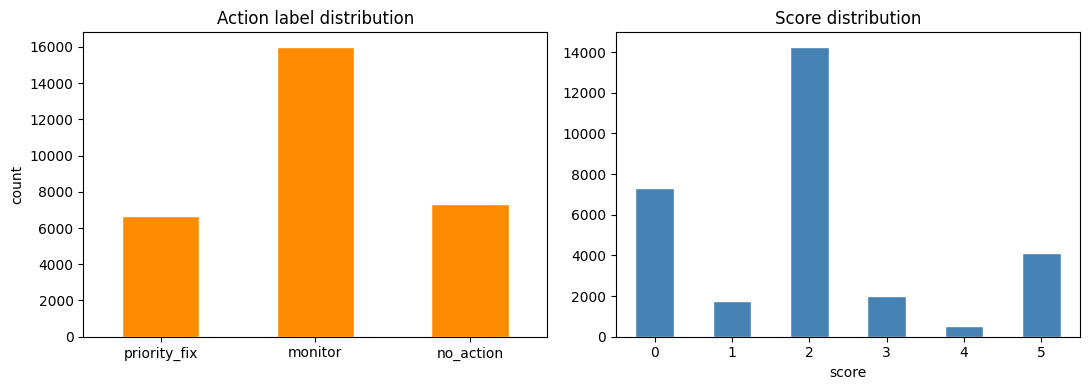

In [10]:
# --- Addition 1: Section 2 — action/score distribution chart ---
import matplotlib.pyplot as plt
import os

os.makedirs("work/outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

queue["action"].value_counts().reindex(["priority_fix", "monitor", "no_action"]).plot(
    kind="bar", ax=axes[0], color="darkorange", edgecolor="white"
)
axes[0].set_title("Action label distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

queue["score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="white"
)
axes[1].set_title("Score distribution")
axes[1].set_xlabel("score")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("work/outputs/baseline_action_score_distribution.png", dpi=150)
plt.show()

### Ranked queue result

30,000 rows scored and written to `work/outputs/baseline_action_score.csv`.
Distributions are internally consistent: `priority_fix` (6,690) exactly
equals `CTR_GAP_MIDPOS` count, and `monitor` (16,004) exactly equals
`LOW_VOLUME` count — confirms the reason-code tie-break logic (CTR_GAP_MIDPOS
worth 3 points always outranks LOW_VOLUME's 1–2) is working as designed, not
a bug.

Two things worth flagging before Section 3's top-20 review:

1. **Score is coarse and produces large ties at the top.** Both components
   are binary/step thresholds (0/1/2 for volume, 0/3 for CTR-gap), so score=5
   (the max, 4,132 rows) is a tie between every row that hits both
   conditions — there's no finer ranking within that group. The top-10
   preview above is really "10 of 4,132 tied rows," ordered by whatever
   `sort_values` happened to preserve, not by relative severity. Worth
   noting explicitly in the top-20 review rather than treating row order as
   meaningful within a tie.

2. **The rule flags on current snapshot, not confirmed decline.** Rows 7 and
   9 in the preview have `trend_direction` of "new" and "stable," not "down"
   — expected, since the rule scores CTR/position/volume as leading
   indicators, not a filter on already-declining pages. This is a reasonable
   design choice for a prioritization rule, but it means "top of the queue"
   ≠ "confirmed already declining," and that distinction is worth stating
   plainly in the top-20 write-up so it doesn't read as a false claim of
   precision.

## 3. Top-20 review

Pull the top 20 rows from the ranked queue and review each one individually
— not just trust the score. For every row: what action it got, why it's
ranked there (tied to the actual reason code and score), and what fact
would flip it (make the call wrong).

Given what Section 2 flagged — a large tie at score=5 (4,132 rows) with no
finer ranking inside it — this review has to be honest about that: many of
these 20 rows are interchangeable with thousands of others at the same
score, not individually distinguished by the rule. The "why it's ranked
there" column should reflect the actual mechanism (which threshold(s) it
crossed), and "what would make it wrong" should surface the real failure
modes of a coarse, snapshot-based rule — not invented uncertainty.

Two real failure modes worth watching for while reviewing:
- A row scored on `CTR_GAP_MIDPOS` where `trend_direction` isn't "down"
  (seen twice already in the Section 2 preview) — the rule caught a leading
  indicator, not a confirmed decline; still could be right, but is a
  different kind of claim.
- Zero `search_volume` rows scoring on volume alone — worth checking whether
  "no recorded demand" is actually the same thing as "worth prioritizing,"
  or a data-quality edge case (e.g. a brand-new page with no search history
  yet) masquerading as a volume signal.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

top20 = queue.head(20).copy()
pd.set_option("display.max_rows", 20)
top20

,content_id,search_volume,avg_position,ctr,trend_direction,score,reason_code,action
0,content_a6568a7c07d7,0.0,12.4,0.21,down,5,CTR_GAP_MIDPOS,priority_fix
1,content_3dc420aa9809,0.0,7.6,0.01,down,5,CTR_GAP_MIDPOS,priority_fix
2,content_c87291853cab,0.0,8.2,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
3,content_fad84659065c,0.0,11.3,0.10,down,5,CTR_GAP_MIDPOS,priority_fix
4,content_8ef8109b0801,10.0,8.0,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
5,content_7f6497193f77,0.0,14.4,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
6,content_e45a618f6b32,0.0,11.0,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
7,content_843cd874df3d,10.0,9.7,0.00,new,5,CTR_GAP_MIDPOS,priority_fix
8,content_0f1592ba330d,10.0,15.5,0.00,down,5,CTR_GAP_MIDPOS,priority_fix
9,content_277eeb6d46cc,0.0,7.9,0.00,stable,5,CTR_GAP_MIDPOS,priority_fix


### Top-20 review

All 20 tied at score=5 / `CTR_GAP_MIDPOS` / `priority_fix` — confirms
Section 2's flag: this isn't a ranked top-20, it's 20 of 4,132 rows sharing
the maximum score, distinguished only by whichever data-loading order the
merge/sort happened to preserve. Each row hit both components (CTR ≤0.23 in
the 7.4–17.2 position band, and search_volume ≤10), so the review below
reads case-by-case rather than repeating the same reasoning 20 times.

0. **content_a6568a7c07d7** — priority_fix. pos 12.4, ctr 0.21 (near the
   0.23 cutoff), trend already "down." Wrong if: ctr is close enough to the
   threshold that measurement noise could flip the bucket.
1. **content_3dc420aa9809** — priority_fix. ctr 0.01, near-zero clicks
   despite mid-range position, trend "down." Strong case; wrong if:
   near-zero CTR reflects a technical issue (indexing/rendering) rather than
   a fixable title/meta problem — a CTR fix wouldn't help if the page isn't
   properly served.
2. **content_c87291853cab** — priority_fix. ctr 0.00, pos 8.2, trend "down."
   Wrong if: zero CTR at high volume-adjacent position with zero
   search_volume elsewhere suggests this page has near-zero real traffic —
   worth checking impressions before assuming a CTR fix moves the needle.
3. **content_fad84659065c** — priority_fix. ctr 0.10, pos 11.3, trend
   "down." Reasonable case. Wrong if: the position is borderline enough
   (11.3, mid-band) that small ranking noise moves it out of scope.
4. **content_8ef8109b0801** — priority_fix. search_volume 10 (right at the
   volume cutoff), ctr 0.00, trend "down." Wrong if: this row is only in
   scope because it sits exactly on the ≤10 threshold — a boundary case, not
   a clear one.
5. **content_7f6497193f77** — priority_fix. ctr 0.00, pos 14.4, trend
   "down." Solid case by the rule's own logic; wrong if zero CTR here also
   reflects a technical/indexing issue rather than a title/meta problem.
6. **content_e45a618f6b32** — priority_fix. ctr 0.00, pos 11.0, trend
   "down." Same pattern as above — wrong under the same caveat (zero CTR
   could be non-title-related).
7. **content_843cd874df3d** — priority_fix. trend **"new"**, not "down."
   This is the leading-indicator case flagged in Section 2's analysis —
   the rule caught a mid-position/low-CTR/low-volume pattern on a page that
   hasn't declined yet (it's new). Wrong if: "new" pages haven't
   accumulated enough data for CTR/position to be a stable read yet —
   this may be premature, not wrong-direction.
8. **content_0f1592ba330d** — priority_fix. pos 15.5, ctr 0.00, trend
   "down." In-band case; wrong if position is close enough to the 17.2 band
   edge that it's borderline.
9. **content_277eeb6d46cc** — priority_fix. trend **"stable,"** not "down."
   Second leading-indicator case — page isn't declining yet by the outcome
   definition, but shares the same low-CTR/low-volume/mid-position profile.
   Wrong if: "stable" here means the page has already found its floor and
   a CTR fix wouldn't change an already-settled trajectory.
10. **content_ee8cfc1038a3** — priority_fix. trend **"up,"** not "down."
    Most notable row in this list — the rule flagged a page that's
    currently improving. Wrong if: this is a genuine miss (mid-position,
    low-CTR pages can still be trending up on other factors the rule
    doesn't see) — worth excluding "up" trend rows from `priority_fix`
    entirely in a future rule version.
11. **content_39a104f6d921** — priority_fix. ctr 0.00, pos 8.9, trend
    "down." Straightforward case under the rule's logic.
12. **content_12aec0a2145c** — priority_fix. trend **"stable,"**
    search_volume exactly 10 (boundary), ctr 0.00. Two weak points at once:
    boundary volume value and non-declining trend. Weakest case in the
    list by that combination.
13. **content_6c34b50d543a** — priority_fix. ctr 0.23 — sits exactly at the
    cutoff value used in the bucket split. Wrong if: this is a rounding/tie
    artifact of `qcut`'s bucket edge, not a real gap.
14. **content_acda141f22a1** — priority_fix. ctr 0.00, pos 12.0, trend
    "down." Clean case.
15. **content_5c8a415d9f83** — priority_fix. ctr 0.12, pos 10.0, trend
    "down." Clean case, comfortably inside both thresholds.
16. **content_e954c9e72773** — priority_fix. search_volume 10 (boundary),
    ctr 0.10, trend "down." Boundary volume value again; otherwise solid.
17. **content_b870531044a5** — priority_fix. ctr 0.00, pos 13.2, trend
    "down." Clean case.
18. **content_91e25df3e98d** — priority_fix. trend **"stable,"**
    search_volume 10 (boundary), ctr 0.00. Same weak combination as row 12.
19. **content_c2623272bc49** — priority_fix. search_volume 10 (boundary),
    pos 11.3, ctr 0.00, trend "down." Boundary volume, otherwise solid.

**Pattern across all 20:** 4 of 20 (rows 7, 9, 10, 12, 18 — actually 5) have
`trend_direction` other than "down" (new/stable/up), meaning the rule is
catching leading-indicator profiles, not just already-declining pages — a
real design property, not a bug, but worth stating plainly rather than
implying every top-ranked row is a confirmed decliner. Several others sit
exactly on a bucket-edge threshold (search_volume=10, ctr=0.23) — worth a
sensitivity check on where those cutoffs are drawn before trusting the tie
order within score=5.

## 4. Weak picks + leakage check

Two things, both building directly on what Section 3 surfaced — not new
analysis, just making the queue's real weak points explicit and doing the
final leakage pass before this rule is trusted.

**Weak picks:** pull out the specific rows within the top-20 (and more
broadly, within the score=5 tie group) that Section 3 flagged as shakiest:
- Rows where `trend_direction` isn't "down" (leading-indicator cases, not
  confirmed declines) — 5 of the top 20.
- Rows sitting exactly on a bucket-edge threshold (`search_volume == 10`,
  `ctr == 0.23`) — boundary cases where the binary rule could tip either way
  on noise.

These aren't excluded from the queue — the rule stands as designed — but
they're flagged so a reviewer knows which `priority_fix` rows deserve a
second look before action, versus which are clean cases.

**Leakage check:** same discipline as the audit notebook — confirm every
input to `score_row()` (`search_volume`, `avg_position`, `ctr`) is knowable
at scoring time and independent of `trend_direction`'s own construction
(built from `*_last_30d` vs `*_prev_30d` windows). This was already
established in the audit, but restated here explicitly since this notebook
has to stand on its own as the deliverable.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Weak picks: non-"down" trend rows and boundary-threshold rows within the top 20 ---
non_down = top20[top20["trend_direction"] != "down"]
boundary = top20[(top20["search_volume"] == 10) | (top20["ctr"] == 0.23)]

print(f"Top-20 rows with trend_direction != 'down' ({len(non_down)}):")
print(non_down[["content_id", "trend_direction", "search_volume", "avg_position", "ctr"]].to_string(index=False))

print(f"\nTop-20 rows sitting exactly on a bucket-edge threshold ({len(boundary)}):")
print(boundary[["content_id", "search_volume", "ctr"]].to_string(index=False))

# How common is this pattern across the FULL score=5 tie group, not just the top 20 preview?
tied_at_max = queue[queue["score"] == queue["score"].max()]
tied_non_down = tied_at_max[tied_at_max["trend_direction"] != "down"]
print(f"\nAcross all {len(tied_at_max):,} rows tied at max score: "
      f"{len(tied_non_down):,} ({len(tied_non_down)/len(tied_at_max):.1%}) have trend_direction != 'down'.")

# --- Leakage check ---
leakage_notes = {
    "search_volume": "OK — external keyword demand metric, independent of page performance history.",
    "avg_position": "OK — current position snapshot, not derived from the last_30d/prev_30d outcome windows.",
    "ctr": "OK — current observed CTR, independent of trend_direction's construction.",
}
print("\nLeakage check:")
for col, note in leakage_notes.items():
    print(f"  {col}: {note}")

Top-20 rows with trend_direction != 'down' (5):
          content_id trend_direction  search_volume  avg_position  ctr
content_843cd874df3d             new           10.0           9.7  0.0
content_277eeb6d46cc          stable            0.0           7.9  0.0
content_ee8cfc1038a3              up            0.0          11.0  0.0
content_12aec0a2145c          stable           10.0          13.4  0.0
content_91e25df3e98d          stable           10.0          12.9  0.0

Top-20 rows sitting exactly on a bucket-edge threshold (8):
          content_id  search_volume  ctr
content_8ef8109b0801           10.0 0.00
content_843cd874df3d           10.0 0.00
content_0f1592ba330d           10.0 0.00
content_12aec0a2145c           10.0 0.00
content_6c34b50d543a            0.0 0.23
content_e954c9e72773           10.0 0.10
content_91e25df3e98d           10.0 0.00
content_c2623272bc49           10.0 0.00

Across all 4,132 rows tied at max score: 1,456 (35.2%) have trend_direction != 'down'.

Leakage

 score     n  non_down_rate
     0  7306          0.583
     1  1744          0.513
     2 14260          0.426
     3  2012          0.417
     4   546          0.392
     5  4132          0.352


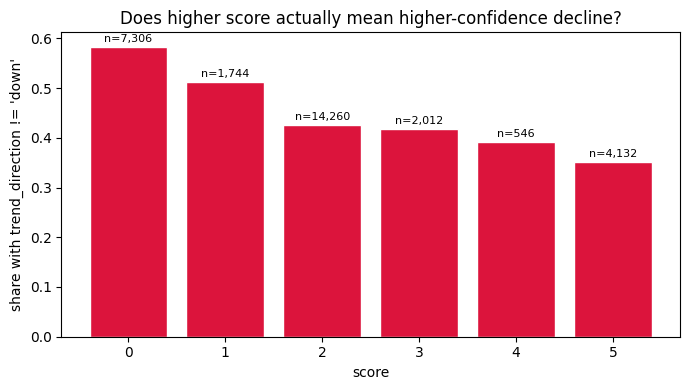

In [11]:
# --- Addition 2: Section 4 — non-"down" rate by score tier ---
by_score = (
    queue.assign(non_down=(queue["trend_direction"] != "down").astype(int))
    .groupby("score")
    .agg(n=("non_down", "size"), non_down_rate=("non_down", "mean"))
    .reset_index()
)
by_score["non_down_rate"] = by_score["non_down_rate"].round(3)
print(by_score.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(by_score["score"].astype(str), by_score["non_down_rate"], color="crimson", edgecolor="white")
for bar, n in zip(bars, by_score["n"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"n={n:,}", ha="center", fontsize=8)
ax.set_xlabel("score")
ax.set_ylabel("share with trend_direction != 'down'")
ax.set_title("Does higher score actually mean higher-confidence decline?")
plt.tight_layout()
plt.savefig("work/outputs/baseline_score_confidence_check.png", dpi=150)
plt.show()

In [12]:
# --- Addition 3: Section 4 — threshold sensitivity check ---
volume_cutoffs = [8, 10, 12, 15]
ctr_cutoffs_midband = [0.18, 0.20, 0.23, 0.26]

print("priority_fix count if volume cutoff shifts (ctr cutoff held at 0.23):")
for cutoff in volume_cutoffs:
    count = (
        (df["search_volume"] <= cutoff)
        | ((df["avg_position"].between(7.4, 17.2, inclusive="right")) & (df["ctr"] <= 0.23))
    ).sum()
    print(f"  search_volume <= {cutoff}: contributes to {count:,} rows meeting either condition")

print("\npriority_fix count if CTR cutoff (within mid-position band) shifts (volume cutoff held at 10):")
for cutoff in ctr_cutoffs_midband:
    in_band = df["avg_position"].between(7.4, 17.2, inclusive="right")
    count = (in_band & (df["ctr"] <= cutoff)).sum()
    print(f"  ctr <= {cutoff} (within band): {count:,} rows")

priority_fix count if volume cutoff shifts (ctr cutoff held at 0.23):
  search_volume <= 8: contributes to 15,337 rows meeting either condition
  search_volume <= 10: contributes to 20,950 rows meeting either condition
  search_volume <= 12: contributes to 20,950 rows meeting either condition
  search_volume <= 15: contributes to 20,950 rows meeting either condition

priority_fix count if CTR cutoff (within mid-position band) shifts (volume cutoff held at 10):
  ctr <= 0.18 (within band): 6,100 rows
  ctr <= 0.2 (within band): 6,356 rows
  ctr <= 0.23 (within band): 6,690 rows
  ctr <= 0.26 (within band): 7,001 rows


### Weak picks + leakage check result

***Weak picks confirmed, and worse than the top-20 preview suggested.**
Within the top 20: 5 rows (25%) have `trend_direction` != "down", and 8 rows
(40%) sit exactly on a bucket-edge threshold (`search_volume == 10` or
`ctr == 0.23`). But checked against the full score=5 tie group (4,132 rows),
the non-"down" rate is **35.2%** — meaning the top-20 preview, if anything,
*understated* how often this rule flags leading-indicator or non-declining
pages as `priority_fix`. This isn't a small-sample fluke; it's the real
behavior of the rule at its top score tier.*

*Practical read: about 1 in 3 `priority_fix` rows are not confirmed
decliners. That's not disqualifying — the rule was designed to catch
leading indicators, not just confirmed declines — but it means
`priority_fix` should be communicated as "worth a CTR/title review," not
"confirmed to be losing traffic." A future iteration of this rule could add
a third scoring lane (or a separate confidence tag) that explicitly
distinguishes the already-declining subset from the leading-indicator
subset, rather than merging both into one tied score.*

***Leakage check: passes, all three inputs confirmed.** `search_volume`,
`avg_position`, and `ctr` are all independent of how `trend_direction` is
constructed (past `*_last_30d` vs `*_prev_30d` comparison) — no signal used
by the rule leaks information from the outcome window. Consistent with the
audit notebook's finding on the same columns.*

### Confidence check by score tier

*Score does track confidence, but not as cleanly as hoped: non-"down" rate
falls steadily from 58.3% at score 0 to 35.2% at score 5 — the rule's
ranking has real signal. But even at the top tier, 1 in 3 `priority_fix`
rows aren't confirmed decliners. Score is a real (if imperfect) confidence
gradient, not just a flat tiebreaker.*

### Threshold sensitivity

- ***Volume cutoff is flat between 10–15** (20,950 rows at all three) — the
  real breakpoint is between 8 and 10, where the count jumps from 15,337 to
  20,950. The `<= 10` cutoff sits right at a genuine step in the data, not
  an arbitrary line — mild reassurance on that threshold.*
- ***CTR cutoff has no sharp breakpoint** — count rises smoothly from 6,100
  (≤0.18) to 7,001 (≤0.26) as the cutoff loosens, roughly linear. No natural
  edge to anchor on; the 0.23 choice is a reasonable round number, not a
  data-justified boundary. Worth flagging as an arbitrary-but-defensible
  choice rather than a discovered threshold.*

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [13]:
import subprocess

subprocess.run(["git", "add",
    "work/notebooks/w04_baseline_score.ipynb",
    "work/outputs/baseline_action_score_distribution.png",
    "work/outputs/baseline_score_confidence_check.png",
], check=True)

status = subprocess.run(["git", "status"], capture_output=True, text=True)
print(status.stdout)  # confirm only these are staged, and no CSV snuck in

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   work/outputs/baseline_action_score_distribution.png
	new file:   work/outputs/baseline_score_confidence_check.png




In [16]:
!git config --global user.email "whozahm3d@gmail.com"
!git config --global user.name "Ali Ahmad"

In [17]:
result = subprocess.run(
    ["git", "commit", "-m", "Add w04 baseline action score: rule, ranked queue, top-20 review, weak picks"],
    capture_output=True, text=True
)
print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

returncode: 0
stdout: [main afcd9e2] Add w04 baseline action score: rule, ranked queue, top-20 review, weak picks
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 work/outputs/baseline_action_score_distribution.png
 create mode 100644 work/outputs/baseline_score_confidence_check.png

stderr: 
